# Install Package

In [1]:
# Install PyTorch dan dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install timm (PyTorch Image Models) - untuk MobileNetV4
!pip install -q timm

# Install library untuk visualisasi dan evaluasi
!pip install -q scikit-learn matplotlib seaborn opencv-python albumentations

# Import Package

In [2]:
# PyTorch & timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

# Image processing
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Data handling
import numpy as np
import pandas as pd
from pathlib import Path
import os
import json
from typing import Tuple, Dict, List
import random

# Visualization & Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Utilities
from tqdm.auto import tqdm
import warnings

# Set random seed

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Config

In [4]:
class Config:

    # ========== PATH CONFIGURATION ==========
    BASE_PATH = "/content/drive/MyDrive/dataset801010"  # ⚠️ SESUAIKAN dengan path Anda
    MATA_PATH = f"{BASE_PATH}/mata"
    INSANG_PATH = f"{BASE_PATH}/insang"
    SAVE_PATH = "/content/drive/MyDrive/hasilv3/Models/SGD/EcaNett"  # Path untuk menyimpan hasil

    # ========== MODEL CONFIGURATION ==========
    # MODEL_NAME = "mobilenetv4_conv_small.e1200_r224_in1k"  # MobileNetV4 Medium
    MODEL_NAME = "mobilenetv4_conv_small"  # MobileNetV4 Medium
    NUM_CLASSES = 2  # segar vs tidak_segar
    IMG_SIZE = 96  # Ukuran input image
    IN_CHANNELS = 3  # RGB

    # ========== FINE-TUNING CONFIGURATION ==========
    # ⚠️ UBAH DI SINI UNTUK SWITCH ANTARA FROM-SCRATCH vs FINE-TUNING
    USE_PRETRAINED = False  # ← SET True untuk fine-tuning, False untuk from scratch
    FREEZE_BACKBONE = False  # ← SET True untuk freeze backbone (hanya train classifier)
    UNFREEZE_LAST_N_LAYERS = 0  # ← Jumlah layer terakhir yang di-unfreeze (0 = freeze semua)

    # ========== ECA-NET CONFIGURATION ==========
    USE_ECA_NET = True  # ← SET True untuk pakai ECA-Net (channel attention), False untuk tanpa ECA-Net

    # ========== TRAINING CONFIGURATION ==========
    BATCH_SIZE = 32  # Bisa diubah sesuai kapasitas GPU (16, 32, 64)
    NUM_EPOCHS = 100  # Jumlah epoch

    # Learning rate disesuaikan otomatis berdasarkan training strategy
    if USE_PRETRAINED and FREEZE_BACKBONE:
        # Fine-tuning dengan frozen backbone: LR lebih besar
        LEARNING_RATE = 1e-5
        WEIGHT_DECAY = 1e-4
    elif USE_PRETRAINED and not FREEZE_BACKBONE:
        # Fine-tuning dengan unfrozen backbone: LR lebih kecil
        LEARNING_RATE = 1e-4
        WEIGHT_DECAY = 1e-4
    else:
        # From scratch: LR standard
        # LEARNING_RATE = 1e-3
        LEARNING_RATE = 0.01
        WEIGHT_DECAY = 1e-4

    # ========== MODEL ARCHITECTURE ==========
    FUSION_METHOD = 'concat'          # ← BARU: 'concat', 'add', 'attention'
    DROPOUT_RATE = 0.2                # ← BARU
    CLASSIFIER_HIDDEN_DIM = 512       # ← BARU

    # ========== LOSS FUNCTION ==========
    LOSS_TYPE = 'focal'               # 'ce', 'focal', 'focal_smooth'
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0
    LABEL_SMOOTHING = 0.1             # (dipakai jika LOSS_TYPE='focal_smooth')

    # ========== OPTIMIZER & SCHEDULER ==========
    OPTIMIZER = "SGD"  # Bisa: "Adam", "SGD", "AdamW"
    ADAM_BETAS = (0.9, 0.999)
    ADAM_EPS = 1e-8
    SGD_MOMENTUM = 0.9


    SCHEDULER = "ReduceLROnPlateau"  # Bisa: "ReduceLROnPlateau", "CosineAnnealing", "StepLR"
    SCHEDULER_FACTOR = 0.5
    SCHEDULER_PATIENCE = 5
    MIN_LR = 1e-6
    STEPLR_STEP_SIZE = 25
    STEPLR_GAMMA = 0.5

    # ========== PREPROCESSING ==========
    APPLY_CLAHE = True  # Apakah menggunakan CLAHE preprocessing
    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_TILE_SIZE = (8, 8)

    # Normalization (ImageNet stats - karena pakai model pretrained architecture)
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]

    # ========== AUGMENTATION ==========
    USE_AUGMENTATION = True
    AUGMENTATION_PARAMS = {

          'rotate_limit': 10,
          'shift_limit': 0.05,
          'zoom_limit': 0.1,
          'brightness_limit': 0.10,
          'contrast_limit': 0.25,
          'blur_limit': 2,
          'noise_prob': 0.03,
          'gamma_limit': (80, 120),

        # 'rotate_limit': 30,       # ← Naikkan dari 20
        # 'shift_limit': 0.15,      # ← Naikkan dari 0.1
        # 'zoom_limit': 0.3,        # ← Naikkan dari 0.2
        # 'brightness_limit': 0.35, # ← Naikkan dari 0.2 (PENTING!)
        # 'contrast_limit': 0.35,   # ← Naikkan dari 0.2 (PENTING!)
        # 'blur_limit': 7,          # ← Naikkan dari 3
        # 'noise_prob': 0.25        # ← Naikkan dari 0.1

        # 'rotate_limit': 20,       # ← TINGGI
        # 'shift_limit': 0.2,       # ← TINGGI
        # 'zoom_limit': 0.3,        # ← TINGGI
        # 'brightness_limit': 0.35, # ← TINGGI
        # 'contrast_limit': 0.35,   # ← TINGGI
        # 'blur_limit': 7,          # ← TINGGI
        # 'noise_prob': 0.3         # ← TINGGI (30% chance noise)
    }

    # ========== DEVICE ==========
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 0  # Untuk DataLoader

    # ========== EARLY STOPPING ==========
    EARLY_STOPPING_PATIENCE = 15   # ← Ubah sesuai kebutuhan (jumlah epoch tanpa improve sebelum stop)

    # ========== FEATURE TYPE ==========
    FEATURE_TYPE = "fusion"  # Bisa diganti: "mata", "insang", atau "fusion"

    def __repr__(self):
        return f"Config(MODEL={self.MODEL_NAME}, FEATURE={self.FEATURE_TYPE}, BATCH_SIZE={self.BATCH_SIZE})"

# Inisialisasi config
config = Config()

# Mount ke Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Verifikasi dataset ada
print("\n📁 Mengecek struktur dataset...")
if os.path.exists(config.BASE_PATH):
    print(f"✅ Dataset ditemukan di: {config.BASE_PATH}")

    # Cek struktur folder mata
    if os.path.exists(config.MATA_PATH):
        print(f"  └─ ✅ Folder mata: {config.MATA_PATH}")
        for split in ['train', 'valid', 'test']:
            path = f"{config.MATA_PATH}/{split}"
            if os.path.exists(path):
                n_segar = len(os.listdir(f"{path}/segar"))
                n_tidak = len(os.listdir(f"{path}/tidak_segar"))
                print(f"      └─ {split}: {n_segar} segar, {n_tidak} tidak_segar")

    # Cek struktur folder insang
    if os.path.exists(config.INSANG_PATH):
        print(f"  └─ ✅ Folder insang: {config.INSANG_PATH}")
        for split in ['train', 'valid', 'test']:
            path = f"{config.INSANG_PATH}/{split}"
            if os.path.exists(path):
                n_segar = len(os.listdir(f"{path}/segar"))
                n_tidak = len(os.listdir(f"{path}/tidak_segar"))
                print(f"      └─ {split}: {n_segar} segar, {n_tidak} tidak_segar")
else:
    print(f"❌ Dataset tidak ditemukan di: {config.BASE_PATH}")
    print("⚠️  Silakan sesuaikan BASE_PATH di Config!")

Mounted at /content/drive

📁 Mengecek struktur dataset...
✅ Dataset ditemukan di: /content/drive/MyDrive/dataset801010
  └─ ✅ Folder mata: /content/drive/MyDrive/dataset801010/mata
      └─ train: 686 segar, 686 tidak_segar
      └─ valid: 86 segar, 86 tidak_segar
      └─ test: 86 segar, 86 tidak_segar
  └─ ✅ Folder insang: /content/drive/MyDrive/dataset801010/insang
      └─ train: 686 segar, 686 tidak_segar
      └─ valid: 86 segar, 86 tidak_segar
      └─ test: 86 segar, 86 tidak_segar


# Inisialisasi Clahe dan Preprocess

In [6]:
def apply_clahe(image, clip_limit=2.0, tile_size=(8, 8)):

    # Convert RGB to LAB color space
    # LAB memisahkan luminance (L) dari color information (A, B)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Split channels
    l, a, b = cv2.split(lab)

    # Apply CLAHE hanya pada L channel (luminance)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    l_clahe = clahe.apply(l)

    # Merge channels kembali
    lab_clahe = cv2.merge([l_clahe, a, b])

    # Convert back to RGB
    image_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return image_clahe


def preprocess_image(image_path, apply_clahe_flag=True, target_size=config.IMG_SIZE):

    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize ke 256x256
    image = cv2.resize(image, (target_size, target_size), interpolation=cv2.INTER_LINEAR)

    # Apply CLAHE jika diaktifkan
    if apply_clahe_flag:
        image = apply_clahe(
            image,
            clip_limit=config.CLAHE_CLIP_LIMIT,
            tile_size=config.CLAHE_TILE_SIZE
        )

    return image

# Inisialisasi Augmentasi

In [7]:
class CLAHETransform:

    def __init__(self, clip_limit=2.0, tile_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_size = tile_size

    def __call__(self, image, **kwargs):
        return apply_clahe(image, self.clip_limit, self.tile_size)


def get_train_transforms(img_size=config.IMG_SIZE, apply_clahe_flag=True):
    p = config.AUGMENTATION_PARAMS

    transforms_list = []

    # CLAHE
    if apply_clahe_flag:
      transforms_list.append(A.Lambda(
          image=CLAHETransform(
              clip_limit=config.CLAHE_CLIP_LIMIT,
              tile_size=config.CLAHE_TILE_SIZE
          ),
          name="CLAHE"
      ))

    # Geometric
    transforms_list.extend([
        A.Rotate(limit=p['rotate_limit'], p=0.5),
        A.ShiftScaleRotate(
            shift_limit=p['shift_limit'],
            scale_limit=p['zoom_limit'],
            rotate_limit=0,
            p=0.5
        ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
    ])

    # Color & Brightness
    transforms_list.extend([
        A.RandomBrightnessContrast(
            brightness_limit=p['brightness_limit'],
            contrast_limit=p['contrast_limit'],
            p=0.7
        ),
        A.RandomGamma(
            gamma_limit=p['gamma_limit'],
            p=0.3
        ),
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=25,
            val_shift_limit=25,
            p=0.3
        ),
    ])

    # Blur & Noise
    transforms_list.extend([
        A.OneOf([
            A.MotionBlur(blur_limit=p['blur_limit'], p=1.0),
            A.MedianBlur(blur_limit=p['blur_limit'], p=1.0),
            A.GaussianBlur(blur_limit=p['blur_limit'], p=1.0),
        ], p=0.4),
        A.GaussNoise(
            var_limit=(10.0, 60.0),
            p=p['noise_prob']
        ),
        A.ISONoise(
            color_shift=(0.01, 0.05),
            intensity=(0.1, 0.5),
            p=0.2
        ),
    ])

    transforms_list.extend([
        A.Normalize(mean=config.MEAN, std=config.STD),
        ToTensorV2()
    ])

    return A.Compose(transforms_list)


def get_valid_transforms(img_size=config.IMG_SIZE, apply_clahe_flag=True):

    transforms_list = []

    # STEP 1: CLAHE (jika diaktifkan)
    if apply_clahe_flag:
        transforms_list.append(
            A.Lambda(
                image=CLAHETransform(
                    clip_limit=config.CLAHE_CLIP_LIMIT,
                    tile_size=config.CLAHE_TILE_SIZE
                ),
                name="CLAHE"
            )
        )

    # STEP 2: Normalization
    transforms_list.append(
        A.Normalize(
            mean=config.MEAN,
            std=config.STD,
            max_pixel_value=255.0
        )
    )

    # STEP 3: Convert to PyTorch tensor
    transforms_list.append(ToTensorV2())

    return A.Compose(transforms_list)

# Test Preprocessing dan Augmentasi

🖼️  Testing dengan: mata_segar_268.jpg


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/functional.py:231: UserWarning: blur_limit: Invalid kernel size range (3, 2). Values less than 3 are not allowed. Range automatically adjusted to (3, 3).
  result = _ensure_min_value(result, min_value, info.field_name)
/tmp/ipykernel_6663/1793628467.py:65: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(


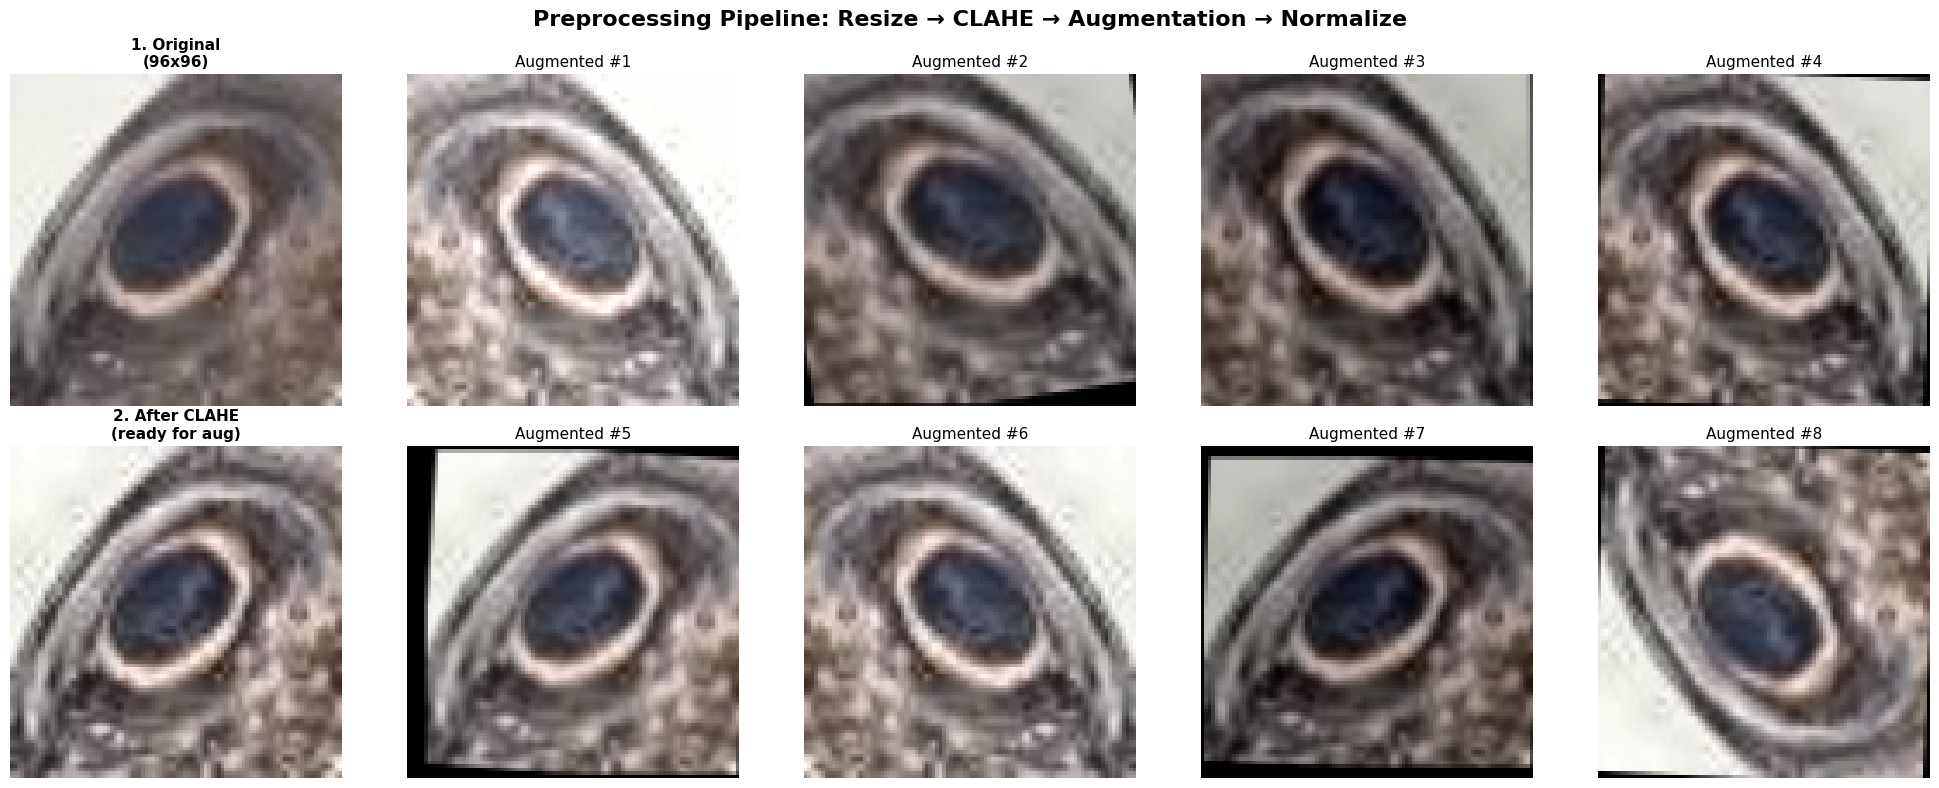

In [8]:
def visualize_preprocessing(image_path, num_augmented=4):

    # Load original image dan resize ke 256x256
    original = cv2.imread(str(image_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original_resized = cv2.resize(original, (config.IMG_SIZE, config.IMG_SIZE), interpolation=cv2.INTER_LINEAR)

    # Apply CLAHE
    clahe_image = apply_clahe(
        original_resized.copy(),
        clip_limit=config.CLAHE_CLIP_LIMIT,
        tile_size=config.CLAHE_TILE_SIZE
    )

    # Get transforms (SUDAH INCLUDE CLAHE di dalamnya)
    train_transform = get_train_transforms(img_size=config.IMG_SIZE, apply_clahe_flag=False)  # CLAHE manual di atas

    # Create subplot
    fig, axes = plt.subplots(2, num_augmented + 1, figsize=(20, 8))

    # Row 1 & 2: Original, CLAHE, dan Augmented versions
    axes[0, 0].imshow(original_resized)
    axes[0, 0].set_title('1. Original\n(96x96)', fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')

    axes[1, 0].imshow(clahe_image)
    axes[1, 0].set_title('2. After CLAHE\n(ready for aug)', fontsize=11, fontweight='bold')
    axes[1, 0].axis('off')

    # Apply augmentation multiple times
    for i in range(num_augmented):
        # Augmented version (dari CLAHE image)
        augmented = train_transform(image=clahe_image.copy())['image']

        # Convert tensor back to numpy for visualization
        # Denormalize
        img_show = augmented.permute(1, 2, 0).numpy()
        img_show = img_show * np.array(config.STD) + np.array(config.MEAN)
        img_show = np.clip(img_show, 0, 1)

        axes[0, i+1].imshow(img_show)
        axes[0, i+1].set_title(f'Augmented #{i+1}', fontsize=11)
        axes[0, i+1].axis('off')

        # Show another augmented version
        augmented2 = train_transform(image=clahe_image.copy())['image']
        img_show2 = augmented2.permute(1, 2, 0).numpy()
        img_show2 = img_show2 * np.array(config.STD) + np.array(config.MEAN)
        img_show2 = np.clip(img_show2, 0, 1)

        axes[1, i+1].imshow(img_show2)
        axes[1, i+1].set_title(f'Augmented #{i+1+num_augmented}', fontsize=11)
        axes[1, i+1].axis('off')

    plt.suptitle('Preprocessing Pipeline: Resize → CLAHE → Augmentation → Normalize',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


# Test dengan sample image
sample_path = f"{config.MATA_PATH}/train/segar"
if os.path.exists(sample_path):
    sample_images = list(Path(sample_path).glob('*.jpg')) + list(Path(sample_path).glob('*.png'))
    if len(sample_images) > 0:
        print(f"🖼️  Testing dengan: {sample_images[0].name}")
        visualize_preprocessing(sample_images[0], num_augmented=4)
    else:
        print("⚠️  Tidak ada sample image ditemukan")
else:
    print(f"⚠️  Path tidak ditemukan: {sample_path}")

# Custom Dataset

In [9]:
class IkanNilaDataset(Dataset):

    def __init__(
        self,
        data_dir,
        feature_type='mata',
        split='train',
        transform=None,
        img_size=config.IMG_SIZE
    ):

        self.data_dir = data_dir
        self.feature_type = feature_type
        self.split = split
        self.transform = transform
        self.img_size = img_size

        # Label mapping
        self.class_to_idx = {'segar': 0, 'tidak_segar': 1}
        self.idx_to_class = {0: 'segar', 1: 'tidak_segar'}

        # Load data paths
        self.data_list = []
        self._load_data()

        print(f"✅ Dataset loaded: {len(self.data_list)} samples")
        print(f"   Feature: {feature_type} | Split: {split}")

    def _load_data(self):

        if self.feature_type in ['mata', 'insang']:
            # Single feature (mata atau insang saja)
            feature_dir = os.path.join(self.data_dir, self.feature_type, self.split)

            for class_name in ['segar', 'tidak_segar']:
                class_dir = os.path.join(feature_dir, class_name)

                if not os.path.exists(class_dir):
                    print(f"⚠️  Warning: {class_dir} tidak ditemukan!")
                    continue

                # Get all image files
                image_files = []
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    image_files.extend(list(Path(class_dir).glob(ext)))

                for img_path in image_files:
                    self.data_list.append({
                        'path': str(img_path),
                        'label': self.class_to_idx[class_name],
                        'class_name': class_name,
                        'filename': img_path.name
                    })

        elif self.feature_type == 'fusion':
            # Fusion: Pakai mata DAN insang (paired by filename)
            mata_dir = os.path.join(self.data_dir, 'mata', self.split)
            insang_dir = os.path.join(self.data_dir, 'insang', self.split)

            for class_name in ['segar', 'tidak_segar']:
                mata_class_dir = os.path.join(mata_dir, class_name)
                insang_class_dir = os.path.join(insang_dir, class_name)

                # Get mata files
                mata_files = {}
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    for f in Path(mata_class_dir).glob(ext):
                        # Extract base name (remove 'mata_' prefix if exists)
                        base_name = f.stem.replace('mata_', '')
                        mata_files[base_name] = str(f)

                # Get insang files
                insang_files = {}
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    for f in Path(insang_class_dir).glob(ext):
                        base_name = f.stem.replace('insang_', '')
                        insang_files[base_name] = str(f)

                # Pair mata & insang dengan nama yang sama
                for base_name in mata_files.keys():
                    if base_name in insang_files:
                        self.data_list.append({
                            'mata_path': mata_files[base_name],
                            'insang_path': insang_files[base_name],
                            'label': self.class_to_idx[class_name],
                            'class_name': class_name,
                            'filename': base_name
                        })
                    else:
                        print(f"⚠️  Warning: Tidak ada pasangan insang untuk {base_name}")

    def _load_and_preprocess(self, image_path):

        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize ke 256x256
        image = cv2.resize(image, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_LINEAR)

        return image

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):

        data_info = self.data_list[idx]
        label = data_info['label']

        if self.feature_type == 'fusion':
            # Load both mata and insang
            mata_image = self._load_and_preprocess(data_info['mata_path'])
            insang_image = self._load_and_preprocess(data_info['insang_path'])

            # Apply transforms
            if self.transform:
                mata_image = self.transform(image=mata_image)['image']
                insang_image = self.transform(image=insang_image)['image']

            return (mata_image, insang_image), label

        else:
            # Load single feature (mata atau insang)
            image = self._load_and_preprocess(data_info['path'])

            # Apply transforms (termasuk CLAHE, augmentasi, normalize, to tensor)
            if self.transform:
                image = self.transform(image=image)['image']

            return image, label

    def get_class_distribution(self):

        distribution = {'segar': 0, 'tidak_segar': 0}
        for data in self.data_list:
            class_name = data['class_name']
            distribution[class_name] += 1
        return distribution

# Create Dataloader

In [10]:
def create_dataloaders(
    data_dir,
    feature_type='mata',
    batch_size=32,
    img_size=config.IMG_SIZE,
    num_workers=2,
    apply_clahe=True
):

    # Get transforms
    train_transform = get_train_transforms(img_size=img_size, apply_clahe_flag=apply_clahe)
    valid_transform = get_valid_transforms(img_size=img_size, apply_clahe_flag=apply_clahe)

    # Create datasets
    train_dataset = IkanNilaDataset(
        data_dir=data_dir,
        feature_type=feature_type,
        split='train',
        transform=train_transform,
        img_size=img_size
    )

    valid_dataset = IkanNilaDataset(
        data_dir=data_dir,
        feature_type=feature_type,
        split='valid',
        transform=valid_transform,
        img_size=img_size
    )

    test_dataset = IkanNilaDataset(
        data_dir=data_dir,
        feature_type=feature_type,
        split='test',
        transform=valid_transform,  # Test pakai valid transform (no augmentation)
        img_size=img_size
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,  # Shuffle untuk training
        num_workers=num_workers,
        pin_memory=True,  # Faster data transfer to GPU
        drop_last=True  # Drop last incomplete batch
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,  # NO shuffle untuk validation
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  # NO shuffle untuk test
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    # Print dataset statistics
    print("\n" + "="*60)
    print("📊 DATASET STATISTICS")
    print("="*60)

    for name, dataset in [('Train', train_dataset),
                          ('Valid', valid_dataset),
                          ('Test', test_dataset)]:
        dist = dataset.get_class_distribution()
        total = sum(dist.values())
        print(f"\n{name} Dataset:")
        print(f"  Total: {total} samples")
        print(f"  - Segar: {dist['segar']} ({dist['segar']/total*100:.1f}%)")
        print(f"  - Tidak Segar: {dist['tidak_segar']} ({dist['tidak_segar']/total*100:.1f}%)")

    print("\n" + "="*60)
    print(f"Batch size: {batch_size}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Valid batches: {len(valid_loader)}")
    print(f"Test batches: {len(test_loader)}")
    print("="*60 + "\n")

    return {
        'train': train_loader,
        'valid': valid_loader,
        'test': test_loader
    }

# Test Dataset dan Dataloader

/tmp/ipykernel_6663/1793628467.py:65: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(


✅ Dataset loaded: 1372 samples
   Feature: fusion | Split: train
✅ Dataset loaded: 172 samples
   Feature: fusion | Split: valid
✅ Dataset loaded: 172 samples
   Feature: fusion | Split: test

📊 DATASET STATISTICS

Train Dataset:
  Total: 1372 samples
  - Segar: 686 (50.0%)
  - Tidak Segar: 686 (50.0%)

Valid Dataset:
  Total: 172 samples
  - Segar: 86 (50.0%)
  - Tidak Segar: 86 (50.0%)

Test Dataset:
  Total: 172 samples
  - Segar: 86 (50.0%)
  - Tidak Segar: 86 (50.0%)

Batch size: 32
Train batches: 42
Valid batches: 6
Test batches: 6

🧪 Testing DataLoader...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Batch loaded successfully!
   Mata images shape: torch.Size([32, 3, 96, 96])
   Insang images shape: torch.Size([32, 3, 96, 96])
   Labels shape: torch.Size([32])
   Labels: [1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1]
   Mata dtype: torch.float32
   Mata range: [-2.118, 2.640]
   Insang dtype: torch.float32
   Insang range: [-2.118, 2.640]


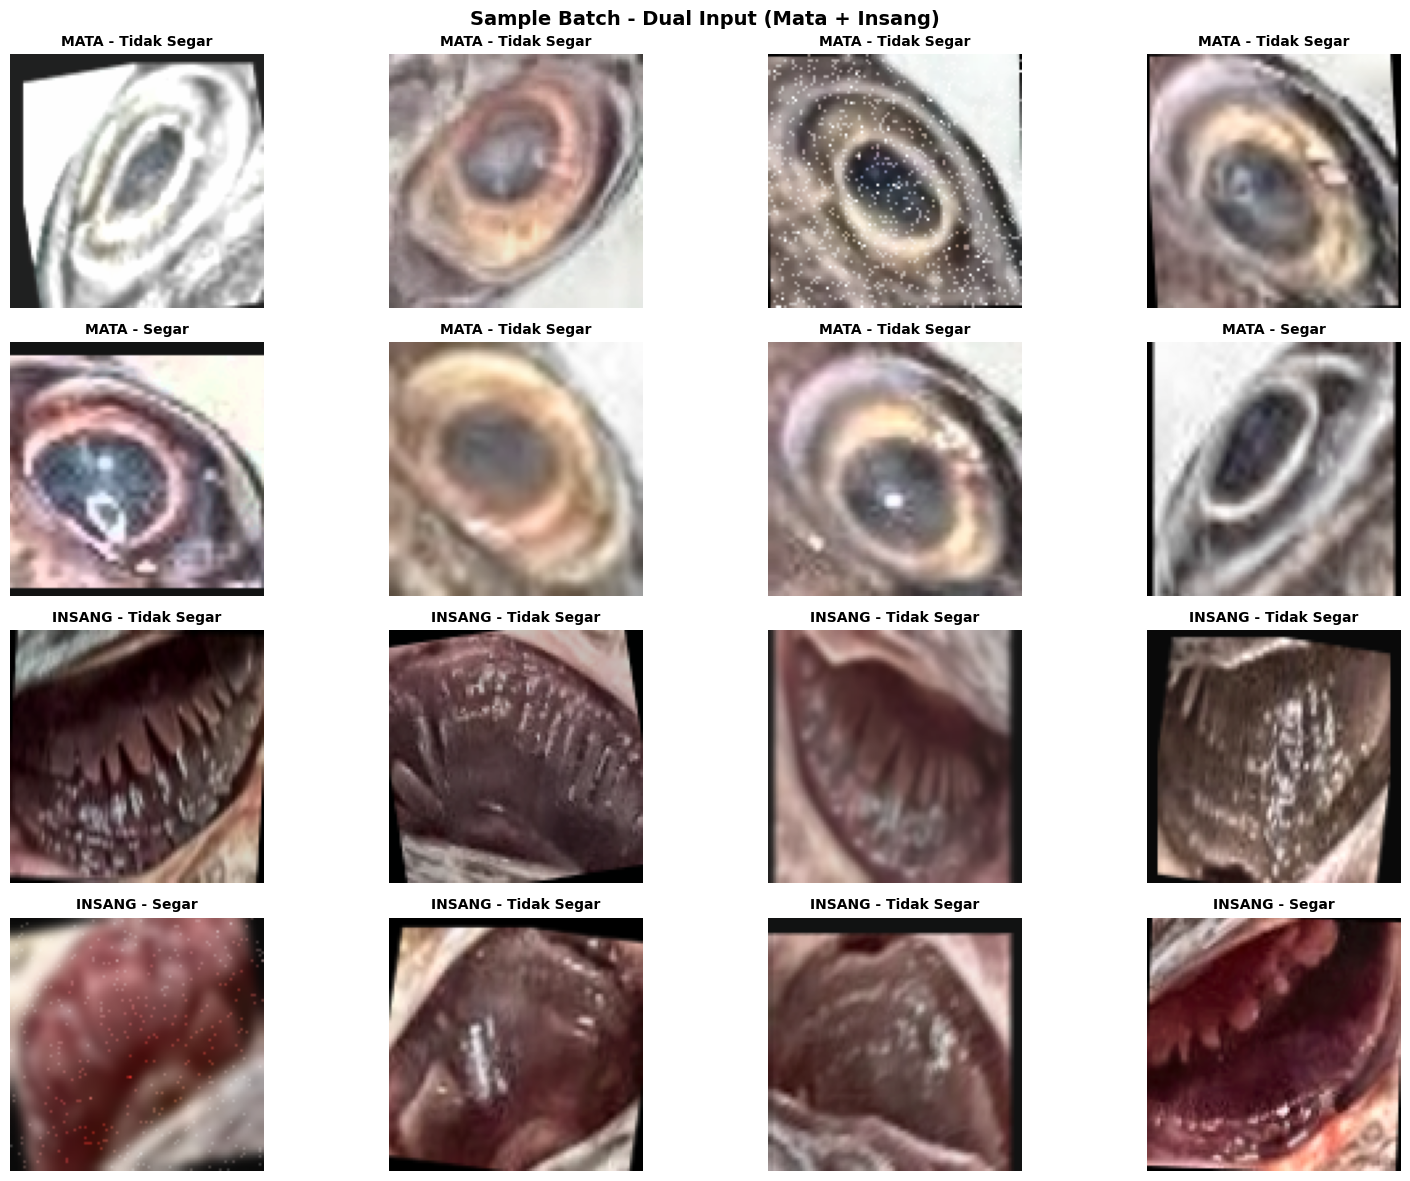

In [11]:
dataloaders = create_dataloaders(
    data_dir=config.BASE_PATH,
    feature_type=config.FEATURE_TYPE,  # 'fusion'
    batch_size=config.BATCH_SIZE,
    img_size=config.IMG_SIZE,
    num_workers=config.NUM_WORKERS,
    apply_clahe=config.APPLY_CLAHE
)

# Test: Load satu batch dari training
print("🧪 Testing DataLoader...")
train_loader = dataloaders['train']

# Get one batch
batch_data = next(iter(train_loader))

# Handle dual input (fusion) vs single input
if config.FEATURE_TYPE == 'fusion':
    # Dual input: batch_data = ((mata_images, insang_images), labels)
    images, labels = batch_data
    mata_images, insang_images = images

    print(f"\n✅ Batch loaded successfully!")
    print(f"   Mata images shape: {mata_images.shape}")  # Expected: (batch_size, 3, 256, 256)
    print(f"   Insang images shape: {insang_images.shape}")  # Expected: (batch_size, 3, 256, 256)
    print(f"   Labels shape: {labels.shape}")  # Expected: (batch_size,)
    print(f"   Labels: {labels.tolist()}")
    print(f"   Mata dtype: {mata_images.dtype}")
    print(f"   Mata range: [{mata_images.min():.3f}, {mata_images.max():.3f}]")
    print(f"   Insang dtype: {insang_images.dtype}")
    print(f"   Insang range: [{insang_images.min():.3f}, {insang_images.max():.3f}]")

    # Visualize samples from batch (dual input)
    def visualize_batch_dual(mata_images, insang_images, labels, num_samples=8):
        num_samples = min(num_samples, len(mata_images))

        fig, axes = plt.subplots(4, num_samples // 2, figsize=(16, 12))
        axes = axes.ravel()

        for i in range(num_samples):
            # Denormalize mata image
            mata_img = mata_images[i].permute(1, 2, 0).numpy()
            mata_img = mata_img * np.array(config.STD) + np.array(config.MEAN)
            mata_img = np.clip(mata_img, 0, 1)

            # Denormalize insang image
            insang_img = insang_images[i].permute(1, 2, 0).numpy()
            insang_img = insang_img * np.array(config.STD) + np.array(config.MEAN)
            insang_img = np.clip(insang_img, 0, 1)

            # Plot mata (top row)
            axes[i].imshow(mata_img)
            label_name = 'Segar' if labels[i].item() == 0 else 'Tidak Segar'
            axes[i].set_title(f'MATA - {label_name}', fontsize=10, fontweight='bold')
            axes[i].axis('off')

            # Plot insang (bottom row)
            axes[i + num_samples].imshow(insang_img)
            axes[i + num_samples].set_title(f'INSANG - {label_name}', fontsize=10, fontweight='bold')
            axes[i + num_samples].axis('off')

        plt.suptitle(f'Sample Batch - Dual Input (Mata + Insang)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    visualize_batch_dual(mata_images, insang_images, labels, num_samples=8)

else:
    # Single input: batch_data = (images, labels)
    images, labels = batch_data

    print(f"\n✅ Batch loaded successfully!")
    print(f"   Images shape: {images.shape}")  # Expected: (batch_size, 3, 256, 256)
    print(f"   Labels shape: {labels.shape}")  # Expected: (batch_size,)
    print(f"   Labels: {labels.tolist()}")
    print(f"   Image dtype: {images.dtype}")
    print(f"   Image range: [{images.min():.3f}, {images.max():.3f}]")

    # Visualize samples from batch (single input)
    def visualize_batch(images, labels, num_samples=8):
        num_samples = min(num_samples, len(images))

        fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 6))
        axes = axes.ravel()

        for i in range(num_samples):
            # Denormalize image
            img = images[i].permute(1, 2, 0).numpy()
            img = img * np.array(config.STD) + np.array(config.MEAN)
            img = np.clip(img, 0, 1)

            # Plot
            axes[i].imshow(img)
            label_name = 'Segar' if labels[i].item() == 0 else 'Tidak Segar'
            axes[i].set_title(f'{label_name}', fontsize=11, fontweight='bold')
            axes[i].axis('off')

        plt.suptitle(f'Sample Batch dari Training Set (Feature: {config.FEATURE_TYPE})',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    visualize_batch(images, labels, num_samples=8)

# inisialisasi Eca-Net

In [12]:
class ECALayer(nn.Module):

    def __init__(self, channels, gamma=2, b=1):
        super(ECALayer, self).__init__()

        # Adaptive kernel size berdasarkan jumlah channels
        # Formula dari paper: k = |log2(C)/gamma + b/gamma|_odd
        t = int(abs((np.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1  # Pastikan kernel size ganjil

        self.avg_pool = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        # 1D Convolution untuk channel attention
        # groups=1 berarti cross-channel interaction
        self.conv = nn.Conv1d(
            1, 1,
            kernel_size=k,
            padding=(k - 1) // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # x shape: (B, C, H, W)
        B, C, H, W = x.size()

        # Global Average Pooling: (B, C, H, W) -> (B, C, 1, 1)
        y = self.avg_pool(x)

        # Reshape untuk 1D conv: (B, C, 1, 1) -> (B, 1, C)
        y = y.squeeze(-1).transpose(-1, -2)

        # 1D Convolution: (B, 1, C) -> (B, 1, C)
        y = self.conv(y)

        # Sigmoid activation: (B, 1, C) -> (B, 1, C)
        y = self.sigmoid(y)

        # Reshape back: (B, 1, C) -> (B, C, 1, 1)
        y = y.transpose(-1, -2).unsqueeze(-1)

        # Channel-wise multiplication (attention weights)
        # (B, C, H, W) * (B, C, 1, 1) -> (B, C, H, W)
        return x * y.expand_as(x)

# Inisialisasi Model

In [13]:
class MobileNetV4WithOptionalECA(nn.Module):
    """
    Dual-Input MobileNetV4 model dengan opsi ECA-Net attention.
    Dikontrol oleh config.USE_ECA_NET:
      - True  → ECA-Net disisipkan di dalam backbone (setelah setiap stage)
      - False → backbone tanpa attention (baseline)

    Arsitektur MobileNetV4 Small memiliki 5 stage:
      blocks[0] → 32ch  → ECA
      blocks[1] → 64ch  → ECA
      blocks[2] → 96ch  → ECA
      blocks[3] → 128ch → ECA
      blocks[4] → 960ch → ECA
      conv_head → 1280ch (output akhir backbone)
    """

    def __init__(
        self,
        model_name='mobilenetv4_conv_small',
        num_classes=2,
        fusion_method='concat',
        use_eca=True,
        dropout_rate=0.5,
        pretrained=False,
        freeze_backbone=False
    ):
        super(MobileNetV4WithOptionalECA, self).__init__()

        self.fusion_method = fusion_method
        self.use_eca = use_eca
        self.pretrained = pretrained
        self.freeze_backbone = freeze_backbone

        print(f"📦 Creating Dual-Input Fusion Model...")
        print(f"   ECA-Net: {'✅ ENABLED (disisipkan di dalam setiap stage backbone)' if use_eca else '❌ DISABLED (baseline)'}")
        print(f"   Pretrained: {pretrained}")
        print(f"   Freeze Backbone: {freeze_backbone}")

        # ========== BACKBONE UNTUK MATA ==========
        print(f"   Creating backbone for MATA...")
        self.backbone_mata = self._create_backbone(model_name, use_eca, pretrained)

        # ========== BACKBONE UNTUK INSANG ==========
        print(f"   Creating backbone for INSANG...")
        self.backbone_insang = self._create_backbone(model_name, use_eca, pretrained)

        # Freeze backbone if requested
        if freeze_backbone:
            self._freeze_backbone()

        # Get feature dimension dari output backbone
        with torch.no_grad():
            dummy = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE)
            feat_mata = self.backbone_mata(dummy)
            self.feature_dim = feat_mata.shape[1]

        print(f"   Feature dim: {self.feature_dim}")

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # ========== FUSION LAYER ==========
        if fusion_method == 'concat':
            fusion_dim = self.feature_dim * 2
            self.fusion = None
        elif fusion_method == 'add':
            fusion_dim = self.feature_dim
            self.fusion = None
        elif fusion_method == 'attention':
            fusion_dim = self.feature_dim * 2
            self.fusion = nn.Sequential(
                nn.Linear(fusion_dim, fusion_dim // 2),
                nn.ReLU(inplace=True),
                nn.Linear(fusion_dim // 2, 2),
                nn.Softmax(dim=1)
            )

        print(f"   Fusion method: {fusion_method}")
        print(f"   Fusion dimension: {fusion_dim}")

        # ========== CLASSIFIER ==========
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(fusion_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.BatchNorm1d(config.CLASSIFIER_HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

        eca_status = "dengan ECA-Net (di dalam backbone)" if use_eca else "tanpa ECA-Net (baseline)"
        print(f"\n✅ Dual-Input Model ({eca_status}) created!")

    def _create_backbone(self, model_name, use_eca, pretrained):
        """
        Buat backbone MobileNetV4.
        Jika use_eca=True: ECALayer disisipkan setelah setiap stage (blocks[i])
        di dalam backbone, sehingga attention bekerja di multiple level fitur.
        """
        backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool=''
        )

        if not use_eca:
            # ── Baseline: backbone murni tanpa modifikasi ──
            class BackboneOnly(nn.Module):
                def __init__(self, bb):
                    super().__init__()
                    self.backbone = bb

                def forward(self, x):
                    return self.backbone(x)

            return BackboneOnly(backbone)

        # ── ECA-Net: sisipkan ECALayer setelah setiap stage di blocks ──
        # Pertama, cari output channel setiap stage dengan dummy forward
        stage_channels = []
        hooks = []
        stage_outputs = {}

        def make_hook(idx):
            def hook(m, inp, out):
                if isinstance(out, torch.Tensor):
                    stage_outputs[idx] = out.shape[1]
            return hook

        for i, stage in enumerate(backbone.blocks):
            hooks.append(stage.register_forward_hook(make_hook(i)))

        with torch.no_grad():
            dummy = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE)
            backbone(dummy)

        for h in hooks:
            h.remove()

        stage_channels = [stage_outputs[i] for i in range(len(backbone.blocks))]
        print(f"     ECA akan disisipkan di {len(stage_channels)} stage: channels={stage_channels}")

        # Buat wrapper yang menyisipkan ECA setelah setiap stage
        class BackboneWithInternalECA(nn.Module):
            def __init__(self, bb, stage_ch):
                super().__init__()
                self.conv_stem = bb.conv_stem
                self.bn1       = bb.bn1

                # Buat ModuleList: setiap stage + ECA-nya
                self.stages  = nn.ModuleList()
                self.eca_layers = nn.ModuleList()
                for stage, ch in zip(bb.blocks, stage_ch):
                    self.stages.append(stage)
                    self.eca_layers.append(ECALayer(ch))

                # Head setelah semua stage
                self.conv_head = bb.conv_head
                self.norm_head = bb.norm_head

            def forward(self, x):
                x = self.conv_stem(x)
                x = self.bn1(x)

                # Lewati setiap stage lalu ECA
                for stage, eca in zip(self.stages, self.eca_layers):
                    x = stage(x)
                    x = eca(x)   # ← ECA setelah setiap stage

                x = self.conv_head(x)
                x = self.norm_head(x)
                return x

        return BackboneWithInternalECA(backbone, stage_channels)

    def _freeze_backbone(self):
        print("   ❄️  Freezing backbone parameters...")
        for param in self.backbone_mata.parameters():
            param.requires_grad = False
        for param in self.backbone_insang.parameters():
            param.requires_grad = False
        print("   ✅ Backbone frozen!")

    def unfreeze_last_n_layers(self, n):
        if n <= 0:
            return
        print(f"   🔥 Unfreezing last {n} layers...")
        all_params_mata   = list(self.backbone_mata.parameters())
        all_params_insang = list(self.backbone_insang.parameters())
        for param in all_params_mata[-n:]:
            param.requires_grad = True
        for param in all_params_insang[-n:]:
            param.requires_grad = True
        print(f"   ✅ Last {n} layers unfrozen!")

    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        if self.fusion is not None:
            for m in self.fusion.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)

    def forward(self, x):
        mata_img, insang_img = x

        feat_mata   = self.backbone_mata(mata_img)
        feat_insang = self.backbone_insang(insang_img)

        feat_mata   = self.global_pool(feat_mata).flatten(1)
        feat_insang = self.global_pool(feat_insang).flatten(1)

        if self.fusion_method == 'concat':
            fused = torch.cat([feat_mata, feat_insang], dim=1)
        elif self.fusion_method == 'add':
            fused = feat_mata + feat_insang
        elif self.fusion_method == 'attention':
            concat_feat       = torch.cat([feat_mata, feat_insang], dim=1)
            attention_weights = self.fusion(concat_feat)
            w_mata   = attention_weights[:, 0:1]
            w_insang = attention_weights[:, 1:2]
            fused = w_mata * feat_mata + w_insang * feat_insang

        logits = self.classifier(fused)
        return logits

    def get_num_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {'total': total, 'trainable': trainable}


# Alias untuk backward compatibility
MobileNetV4_ECANet = MobileNetV4WithOptionalECA

print("✅ MobileNetV4WithOptionalECA class created!")
print("   → USE_ECA_NET = True  : ECA disisipkan di dalam setiap stage backbone")
print("   → USE_ECA_NET = False : MobileNetV4 saja (baseline, tanpa attention)")


✅ MobileNetV4WithOptionalECA class created!
   → USE_ECA_NET = True  : ECA disisipkan di dalam setiap stage backbone
   → USE_ECA_NET = False : MobileNetV4 saja (baseline, tanpa attention)


# Create & Test Model

In [14]:
# Create model
# USE_ECA_NET dari config mengontrol apakah ECA-Net dipakai atau tidak
model = MobileNetV4WithOptionalECA(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    fusion_method=config.FUSION_METHOD,
    use_eca=config.USE_ECA_NET,               # ← True: dengan ECA-Net | False: tanpa ECA-Net
    dropout_rate=config.DROPOUT_RATE,
    pretrained=config.USE_PRETRAINED,
    freeze_backbone=config.FREEZE_BACKBONE
)

if config.USE_PRETRAINED and config.UNFREEZE_LAST_N_LAYERS > 0:
    model.unfreeze_last_n_layers(config.UNFREEZE_LAST_N_LAYERS)

# Move to device (GPU/CPU)
model = model.to(config.DEVICE)

# Get model parameters
params_info = model.get_num_parameters()
print(f"\n📊 Model Parameters:")
print(f"   Total: {params_info['total']:,}")
print(f"   Trainable: {params_info['trainable']:,}")
print(f"   Size: ~{params_info['total'] * 4 / 1024 / 1024:.2f} MB (FP32)")

# Test forward pass
print(f"\n🧪 Testing forward pass...")
# Test dengan dual input
dummy_mata = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(config.DEVICE)
dummy_insang = torch.randn(2, 3, config.IMG_SIZE, config.IMG_SIZE).to(config.DEVICE)

with torch.no_grad():
    output = model((dummy_mata, dummy_insang))

print(f"   Input (mata): {dummy_mata.shape}")
print(f"   Input (insang): {dummy_insang.shape}")
print(f"   Output: {output.shape}")

# Model summary
print(f"\n📋 Model Summary:")
print(f"   Backbone: MobileNetV4 Medium")
print(f"   Attention: ECA-Net (positions: [3, 6, 9])")
print(f"   Input size: 96x96x3")
print(f"   Output classes: {config.NUM_CLASSES}")
print(f"   Training mode: FROM SCRATCH (no pretrained weights)")

print("\n✅ Model ready for training!")

📦 Creating Dual-Input Fusion Model...
   ECA-Net: ✅ ENABLED (disisipkan di dalam setiap stage backbone)
   Pretrained: False
   Freeze Backbone: False
   Creating backbone for MATA...
     ECA akan disisipkan di 5 stage: channels=[32, 64, 96, 128, 960]
   Creating backbone for INSANG...
     ECA akan disisipkan di 5 stage: channels=[32, 64, 96, 128, 960]
   Feature dim: 1280
   Fusion method: concat
   Fusion dimension: 2560

✅ Dual-Input Model (dengan ECA-Net (di dalam backbone)) created!

📊 Model Parameters:
   Total: 6,299,368
   Trainable: 6,299,368
   Size: ~24.03 MB (FP32)

🧪 Testing forward pass...
   Input (mata): torch.Size([2, 3, 96, 96])
   Input (insang): torch.Size([2, 3, 96, 96])
   Output: torch.Size([2, 2])

📋 Model Summary:
   Backbone: MobileNetV4 Medium
   Attention: ECA-Net (positions: [3, 6, 9])
   Input size: 96x96x3
   Output classes: 2
   Training mode: FROM SCRATCH (no pretrained weights)

✅ Model ready for training!


# Inisialisasi Loss Function

In [15]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Softmax
        probs = torch.softmax(inputs, dim=1)

        # One-hot encoding
        targets_one_hot = torch.zeros_like(inputs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        # Get probability for true class
        p_t = (probs * targets_one_hot).sum(dim=1)

        # Focal weight
        focal_weight = (1 - p_t) ** self.gamma

        # Cross entropy loss
        ce_loss = -torch.log(p_t + 1e-8)

        # Focal loss
        focal_loss = self.alpha * focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class FocalLossWithLabelSmoothing(nn.Module):

    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.1, reduction='mean'):
        super(FocalLossWithLabelSmoothing, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)

        # One-hot encoding
        targets_one_hot = torch.zeros_like(inputs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        # Apply label smoothing
        # Formula: smooth_label = (1 - smoothing) * one_hot + smoothing / num_classes
        # Example dengan smoothing=0.1, num_classes=2:
        #   [1, 0] → [1*0.9 + 0.1/2, 0*0.9 + 0.1/2] = [0.95, 0.05]
        #   [0, 1] → [0*0.9 + 0.1/2, 1*0.9 + 0.1/2] = [0.05, 0.95]
        targets_smooth = targets_one_hot * (1 - self.smoothing) + self.smoothing / num_classes

        # Softmax
        probs = torch.softmax(inputs, dim=1)

        # Get probability for smoothed labels
        p_t = (probs * targets_smooth).sum(dim=1)

        # Focal weight
        focal_weight = (1 - p_t) ** self.gamma

        # Cross entropy loss
        ce_loss = -torch.log(p_t + 1e-8)

        # Focal loss
        focal_loss = self.alpha * focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


def get_loss_function():
    if config.LOSS_TYPE == 'ce':
        return nn.CrossEntropyLoss()

    elif config.LOSS_TYPE == 'focal':
        return FocalLoss(
            alpha=config.FOCAL_ALPHA,
            gamma=config.FOCAL_GAMMA
        )

    elif config.LOSS_TYPE == 'focal_smooth':
        return FocalLossWithLabelSmoothing(
            alpha=config.FOCAL_ALPHA,
            gamma=config.FOCAL_GAMMA,
            smoothing=config.LABEL_SMOOTHING
        )

    else:
        raise ValueError(f"Unknown loss type: {config.LOSS_TYPE}")

criterion = get_loss_function()

# Inisialisasi Optimizer

In [16]:
def get_optimizer(model):
    if config.OPTIMIZER == 'Adam':
        return optim.Adam(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY,
            betas=config.ADAM_BETAS,
            eps=config.ADAM_EPS
        )

    elif config.OPTIMIZER == 'AdamW':
        return optim.AdamW(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY,
            betas=config.ADAM_BETAS,
            eps=config.ADAM_EPS
        )

    elif config.OPTIMIZER == 'SGD':
        return optim.SGD(
            model.parameters(),
            lr=config.LEARNING_RATE,
            momentum=config.SGD_MOMENTUM,
            weight_decay=config.WEIGHT_DECAY,
            nesterov=True
        )

    else:
        raise ValueError(f"Unknown optimizer: {config.OPTIMIZER}")

optimizer = get_optimizer(model)


# Create optimizer
optimizer = get_optimizer(model)

print("✅ Optimizer created!")
print(f"   Type: {config.OPTIMIZER}")
print(f"   Learning Rate: {config.LEARNING_RATE}")
print(f"   Weight Decay: {config.WEIGHT_DECAY}")

✅ Optimizer created!
   Type: SGD
   Learning Rate: 0.01
   Weight Decay: 0.0001


# inisialisasi Scheduler

In [17]:
def get_scheduler(optimizer, steps_per_epoch=None):
    if config.SCHEDULER == 'ReduceLROnPlateau':
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=config.SCHEDULER_FACTOR,
            patience=config.SCHEDULER_PATIENCE,
            min_lr=config.MIN_LR
        )

    elif config.SCHEDULER == 'CosineAnnealing':
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config.NUM_EPOCHS,
            eta_min=config.MIN_LR
        )

    elif config.SCHEDULER == 'StepLR':
        return optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config.STEPLR_STEP_SIZE,
            gamma=config.STEPLR_GAMMA
        )

    elif config.SCHEDULER == 'OneCycleLR':
        return optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=config.LEARNING_RATE * 10,
            epochs=config.NUM_EPOCHS,
            steps_per_epoch=steps_per_epoch,
            pct_start=0.3,
            anneal_strategy='cos'
        )

    else:
        raise ValueError(f"Unknown scheduler: {config.SCHEDULER}")

    return scheduler


# Create scheduler

scheduler = get_scheduler(optimizer, steps_per_epoch=len(dataloaders['train']))

print("✅ Scheduler created!")
print(f"   Type: {config.SCHEDULER}")
if config.SCHEDULER == 'ReduceLROnPlateau':
    print(f"   Factor: 0.5 (halve LR when plateau)")
    print(f"   Patience: 5 epochs")
    print(f"   Min LR: 1e-7")

✅ Scheduler created!
   Type: ReduceLROnPlateau
   Factor: 0.5 (halve LR when plateau)
   Patience: 5 epochs
   Min LR: 1e-7


# Inisialisasi Early Stopping

In [18]:
class EarlyStopping:

    def __init__(self, patience=15, min_delta=0.0, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

        if mode == 'min':
            self.monitor_op = lambda x, y: x < y - min_delta
        else:
            self.monitor_op = lambda x, y: x > y + min_delta

    def __call__(self, score):

        if self.best_score is None:
            self.best_score = score
            return False

        if self.monitor_op(score, self.best_score):
            # Ada improvement
            self.best_score = score
            self.counter = 0
            return False
        else:
            # Tidak ada improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
            return False

    def reset(self):
        self.counter = 0
        self.best_score = None
        self.early_stop = False


# Create early stopping
early_stopping = EarlyStopping(
    patience=config.EARLY_STOPPING_PATIENCE,  # 15 dari config
    min_delta=0.001,  # Minimal penurunan 0.001 dianggap improvement
    mode='min'  # Minimize validation loss
)

print("✅ Early Stopping created!")
print(f"   Patience: {config.EARLY_STOPPING_PATIENCE} epochs")
print(f"   Min Delta: 0.001")
print(f"   Mode: minimize validation loss")

✅ Early Stopping created!
   Patience: 15 epochs
   Min Delta: 0.001
   Mode: minimize validation loss


# Training Utilities

In [19]:
class AverageMeter:

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target):

    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        correct = pred.eq(target).sum().item()
        acc = correct / target.size(0) * 100.0
    return acc


def save_checkpoint(state, is_best, filepath='checkpoint.pth'):

    torch.save(state, filepath)
    if is_best:
        best_path = filepath.replace('.pth', '_best.pth')
        torch.save(state, best_path)
        print(f"   💾 Best model saved: {best_path}")


print("✅ Training utilities created!")
print("   - AverageMeter: untuk tracking metrics")
print("   - accuracy(): compute accuracy")
print("   - save_checkpoint(): save model states")

✅ Training utilities created!
   - AverageMeter: untuk tracking metrics
   - accuracy(): compute accuracy
   - save_checkpoint(): save model states


# Summary setup

In [20]:
print("\n" + "="*70)
print("🎯 TRAINING SETUP SUMMARY")
print("="*70)

print("\n📊 MODEL:")
print(f"   Architecture: MobileNetV4 Medium + ECA-Net")
print(f"   Parameters: {model.get_num_parameters()['total']:,}")

print("\n📁 DATASET:")
train_dist = dataloaders['train'].dataset.get_class_distribution()
valid_dist = dataloaders['valid'].dataset.get_class_distribution()
test_dist = dataloaders['test'].dataset.get_class_distribution()
print(f"   Feature: {config.FEATURE_TYPE}")
print(f"   Train: {sum(train_dist.values())} samples")
print(f"   Valid: {sum(valid_dist.values())} samples")
print(f"   Test: {sum(test_dist.values())} samples")

print("\n⚙️ HYPERPARAMETERS:")
print(f"   Batch Size: {config.BATCH_SIZE}")
print(f"   Epochs: {config.NUM_EPOCHS}")
print(f"   Initial LR: {config.LEARNING_RATE}")
print(f"   Weight Decay: {config.WEIGHT_DECAY}")
print(f"   Optimizer: {config.OPTIMIZER}")
print(f"   Scheduler: {config.SCHEDULER}")
print(f"   Loss: Focal Loss (α=0.25, γ=2.0)")

print("\n🔧 PREPROCESSING:")
print(f"   Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"   CLAHE: {config.APPLY_CLAHE}")
print(f"   Augmentation: {config.USE_AUGMENTATION}")
print(f"   Normalization: ImageNet stats")

print("\n🛑 REGULARIZATION:")
print(f"   Early Stopping Patience: {config.EARLY_STOPPING_PATIENCE}")
print(f"   Dropout Rate: 0.2")

print("\n💻 DEVICE:")
print(f"   {config.DEVICE}")

print("\n" + "="*70)
print("✅ Ready to start training!")
print("="*70 + "\n")


🎯 TRAINING SETUP SUMMARY

📊 MODEL:
   Architecture: MobileNetV4 Medium + ECA-Net
   Parameters: 6,299,368

📁 DATASET:
   Feature: fusion
   Train: 1372 samples
   Valid: 172 samples
   Test: 172 samples

⚙️ HYPERPARAMETERS:
   Batch Size: 32
   Epochs: 100
   Initial LR: 0.01
   Weight Decay: 0.0001
   Optimizer: SGD
   Scheduler: ReduceLROnPlateau
   Loss: Focal Loss (α=0.25, γ=2.0)

🔧 PREPROCESSING:
   Image Size: 96x96
   CLAHE: True
   Augmentation: True
   Normalization: ImageNet stats

🛑 REGULARIZATION:
   Early Stopping Patience: 15
   Dropout Rate: 0.2

💻 DEVICE:
   cpu

✅ Ready to start training!



# Training and Validation Function

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, is_fusion=False):

    model.train()

    losses = AverageMeter()
    accuracies = AverageMeter()

    pbar = tqdm(dataloader, desc=f'Epoch {epoch} [TRAIN]', leave=False)

    for batch_idx, (images, labels) in enumerate(pbar):

        # Dual input: images adalah tuple (mata, insang)
        mata_img, insang_img = images
        mata_img = mata_img.to(device, non_blocking=True)
        insang_img = insang_img.to(device, non_blocking=True)
        images = (mata_img, insang_img)
        batch_size = mata_img.size(0)

        labels = labels.to(device, non_blocking=True)

        # Forward pass
        outputs = model((mata_img, insang_img))
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Compute accuracy
        acc = accuracy(outputs, labels)

        # Update meters
        losses.update(loss.item(), batch_size)
        accuracies.update(acc, batch_size)

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{losses.avg:.4f}',
            'Acc': f'{accuracies.avg:.2f}%'
        })

    return {
        'loss': losses.avg,
        'acc': accuracies.avg
    }

def validate(model, dataloader, criterion, device, epoch, phase='VALID', is_fusion=False):

    model.eval()

    losses = AverageMeter()
    accuracies = AverageMeter()

    all_preds = []
    all_labels = []
    all_probs = []

    pbar = tqdm(dataloader, desc=f'Epoch {epoch} [{phase}]', leave=False)

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):

            # Move to device

            mata_img, insang_img = images
            mata_img = mata_img.to(device, non_blocking=True)
            insang_img = insang_img.to(device, non_blocking=True)
            images = (mata_img, insang_img)
            batch_size = mata_img.size(0)

            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model((mata_img, insang_img))
            loss = criterion(outputs, labels)

            # Compute accuracy
            acc = accuracy(outputs, labels)

            # Get predictions
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            # Store
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            # Update meters
            losses.update(loss.item(), batch_size)
            accuracies.update(acc, batch_size)

            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{losses.avg:.4f}',
                'Acc': f'{accuracies.avg:.2f}%'
            })

    return {
        'loss': losses.avg,
        'acc': accuracies.avg,
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels),
        'probabilities': np.array(all_probs)
    }

print("✅ Training function created!")
print("✅ Validation function created!")

✅ Training function created!
✅ Validation function created!


# Training Loop

In [22]:
def train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    early_stopping,
    num_epochs,
    device,
    save_dir='./checkpoints',
    start_epoch=1,
    saved_history=None
):

    os.makedirs(save_dir, exist_ok=True)

    # History untuk tracking
    if saved_history is not None:
        history = saved_history
    else:
        history = {
            'train_loss': [],
            'train_acc': [],
            'valid_loss': [],
            'valid_acc': [],
            'learning_rates': []
        }

    # Path file TXT history live (ditulis setiap epoch)
    live_history_path = os.path.join(save_dir, 'training_log.txt')

    # Jika resume, tulis header lanjutan
    if start_epoch == 1:
        with open(live_history_path, 'w') as f:
            eca_status = "dengan ECA-Net" if config.USE_ECA_NET else "tanpa ECA-Net (Baseline)"
            f.write("=" * 80 + "\n")
            f.write(f"TRAINING LOG - MobileNetV4 Small {eca_status}\n")
            f.write(f"Model     : {config.MODEL_NAME}\n")
            f.write(f"ECA-Net   : {config.USE_ECA_NET}\n")
            f.write(f"Optimizer : {config.OPTIMIZER}  |  LR: {config.LEARNING_RATE}\n")
            f.write(f"Scheduler : {config.SCHEDULER}\n")
            f.write(f"Batch Size: {config.BATCH_SIZE}  |  Max Epochs: {num_epochs}\n")
            f.write(f"Early Stop Patience: {config.EARLY_STOPPING_PATIENCE}\n")
            f.write("=" * 80 + "\n")
            f.write(f"{'Epoch':<8}{'LR':<12}{'Train Loss':<14}{'Train Acc':<14}{'Val Loss':<14}{'Val Acc':<14}{'ES Counter'}\n")
            f.write("-" * 80 + "\n")
    else:
        with open(live_history_path, 'a') as f:
            f.write(f"\n[Resume dari epoch {start_epoch}]\n")
            f.write("-" * 80 + "\n")

    # Best model tracking
    best_valid_loss = float('inf')
    best_epoch = 0

    print("\n" + "=" * 70)
    print("🚀 STARTING TRAINING")
    print("=" * 70 + "\n")

    for epoch in range(start_epoch, num_epochs + 1):
        print(f"\n{'=' * 70}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"{'=' * 70}")

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rates'].append(current_lr)
        print(f"Learning Rate: {current_lr:.2e}")

        # ========== TRAINING ==========
        train_metrics = train_one_epoch(
            model=model,
            dataloader=dataloaders['train'],
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epoch=epoch
        )

        # ========== VALIDATION ==========
        valid_metrics = validate(
            model=model,
            dataloader=dataloaders['valid'],
            criterion=criterion,
            device=device,
            epoch=epoch,
            phase='VALID'
        )

        # Update history
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['acc'])
        history['valid_loss'].append(valid_metrics['loss'])
        history['valid_acc'].append(valid_metrics['acc'])

        # ========== EARLY STOPPING CHECK ==========
        es_triggered = early_stopping(valid_metrics['loss'])
        es_counter = early_stopping.counter

        # Print epoch summary
        print(f"\n📊 Epoch {epoch} Summary:")
        print(f"   Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['acc']:.2f}%")
        print(f"   Valid Loss: {valid_metrics['loss']:.4f} | Valid Acc: {valid_metrics['acc']:.2f}%")
        print(f"   Early Stop Counter: {es_counter}/{config.EARLY_STOPPING_PATIENCE}")

        # ========== TULIS KE TXT SETIAP EPOCH ==========
        with open(live_history_path, 'a') as f:
            f.write(
                f"{epoch:<8}"
                f"{current_lr:<12.2e}"
                f"{train_metrics['loss']:<14.4f}"
                f"{train_metrics['acc']:<14.2f}"
                f"{valid_metrics['loss']:<14.4f}"
                f"{valid_metrics['acc']:<14.2f}"
                f"{es_counter}/{config.EARLY_STOPPING_PATIENCE}\n"
            )

        # ========== LEARNING RATE SCHEDULER ==========
        if config.SCHEDULER == 'StepLR':
            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']
        elif config.SCHEDULER == 'ReduceLROnPlateau':
            scheduler.step(valid_metrics['loss'])
            current_lr = optimizer.param_groups[0]['lr']
        elif config.SCHEDULER == 'CosineAnnealing':
            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']

        # ========== SAVE BEST MODEL ==========
        if valid_metrics['loss'] < best_valid_loss:
            best_valid_loss = valid_metrics['loss']
            best_epoch = epoch

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'valid_loss': valid_metrics['loss'],
                'valid_acc': valid_metrics['acc'],
                'config': config
            }

            save_path = os.path.join(save_dir, 'best_model.pth')
            torch.save(checkpoint, save_path)
            print(f"   💾 Best model saved! (Valid Loss: {valid_metrics['loss']:.4f})")

        # ========== SAVE CHECKPOINT SETIAP 10 EPOCHS ==========
        if epoch % 10 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'valid_loss': valid_metrics['loss'],
                'valid_acc': valid_metrics['acc'],
                'config': config
            }

            save_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pth')
            torch.save(checkpoint, save_path)
            print(f"   💾 Checkpoint saved: epoch_{epoch}.pth")

        # ========== EARLY STOPPING ==========
        if es_triggered:
            print(f"\n🛑 Early stopping triggered at epoch {epoch}")
            print(f"   Best validation loss: {best_valid_loss:.4f} at epoch {best_epoch}")
            with open(live_history_path, 'a') as f:
                f.write("-" * 80 + "\n")
                f.write(f"🛑 Early stopping triggered at epoch {epoch}\n")
                f.write(f"   Best val loss: {best_valid_loss:.4f} at epoch {best_epoch}\n")
            break

    # ========== TRAINING SELESAI ==========
    print("\n" + "=" * 70)
    print("✅ TRAINING COMPLETED!")
    print("=" * 70)
    print(f"\n🏆 Best Model:")
    print(f"   Epoch: {best_epoch}")
    print(f"   Valid Loss: {best_valid_loss:.4f}")
    print(f"   Valid Acc: {history['valid_acc'][best_epoch - 1]:.2f}%")

    # Tulis summary akhir ke TXT
    with open(live_history_path, 'a') as f:
        f.write("=" * 80 + "\n")
        f.write("TRAINING COMPLETED\n")
        f.write(f"Best Epoch  : {best_epoch}\n")
        f.write(f"Best Val Loss: {best_valid_loss:.4f}\n")
        f.write(f"Best Val Acc : {history['valid_acc'][best_epoch - 1]:.2f}%\n")
        f.write("=" * 80 + "\n")

    print(f"\n📄 Live training log saved: {live_history_path}")

    # Save final history JSON (tetap ada, tidak dihilangkan)
    history_path = os.path.join(save_dir, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=4)
    print(f"💾 Training history (JSON) saved: {history_path}")

    return history


print("✅ Main training loop created!")
print("   → Early stopping: AKTIF")
print("   → Live TXT log  : training_log.txt (ditulis setiap epoch)")
print("   → JSON history  : training_history.json (ditulis setelah training)")


✅ Main training loop created!
   → Early stopping: AKTIF
   → Live TXT log  : training_log.txt (ditulis setiap epoch)
   → JSON history  : training_history.json (ditulis setelah training)


# Start Training

In [23]:
import glob

checkpoint_dir = os.path.join(config.SAVE_PATH, f'checkpoints_{config.FEATURE_TYPE}')
os.makedirs(checkpoint_dir, exist_ok=True)

def find_latest_checkpoint(save_dir):
    checkpoints = glob.glob(os.path.join(save_dir, 'checkpoint_epoch_*.pth'))
    if not checkpoints:
        return None, 0
    latest = max(checkpoints, key=lambda x: int(x.split('_epoch_')[-1].replace('.pth', '')))
    epoch_num = int(latest.split('_epoch_')[-1].replace('.pth', ''))
    return latest, epoch_num

checkpoint_path, last_epoch = find_latest_checkpoint(checkpoint_dir)

if checkpoint_path is not None:
    print(f"📂 Checkpoint ditemukan: epoch {last_epoch}")
    print(f"   Path: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = last_epoch + 1
    print(f"✅ Resume dari epoch {start_epoch}/{config.NUM_EPOCHS}")
else:
    start_epoch = 1
    print("🚀 Tidak ada checkpoint, mulai fresh dari epoch 1")

# Load history lama kalau ada
history_path = os.path.join(checkpoint_dir, 'training_history.json')
if os.path.exists(history_path) and start_epoch > 1:
    with open(history_path, 'r') as f:
        saved_history = json.load(f)
    print(f"📊 History lama ditemukan: {len(saved_history['train_loss'])} epoch tersimpan")
else:
    saved_history = None
    print("📊 Mulai history baru")

# Start training
history = train_model(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    early_stopping=early_stopping,
    num_epochs=config.NUM_EPOCHS,
    device=config.DEVICE,
    save_dir=checkpoint_dir,
    start_epoch=start_epoch,
    saved_history=saved_history
)

print("\n🎉 Training process finished!")

🚀 Tidak ada checkpoint, mulai fresh dari epoch 1
📊 Mulai history baru

🚀 STARTING TRAINING


Epoch 1/100
Learning Rate: 1.00e-02


Epoch 1 [TRAIN]:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch 1 [VALID]:   0%|          | 0/6 [00:00<?, ?it/s]


📊 Epoch 1 Summary:
   Train Loss: 1.3212 | Train Acc: 66.22%
   Valid Loss: 0.8243 | Valid Acc: 80.81%
   Early Stop Counter: 0/15
   💾 Best model saved! (Valid Loss: 0.8243)

Epoch 2/100
Learning Rate: 1.00e-02


Epoch 2 [TRAIN]:   0%|          | 0/42 [00:00<?, ?it/s]

...

Epoch 23 [VALID]:   0%|          | 0/6 [00:00<?, ?it/s]


📊 Epoch 23 Summary:
   Train Loss: 0.0231 | Train Acc: 94.87%
   Valid Loss: 0.1725 | Valid Acc: 65.12%
   Early Stop Counter: 14/15

Epoch 24/100
Learning Rate: 2.50e-03


Epoch 24 [TRAIN]:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch 24 [VALID]:   0%|          | 0/6 [00:00<?, ?it/s]


📊 Epoch 24 Summary:
   Train Loss: 0.0268 | Train Acc: 94.94%
   Valid Loss: 0.1420 | Valid Acc: 69.19%
   Early Stop Counter: 15/15

🛑 Early stopping triggered at epoch 24
   Best validation loss: 0.0319 at epoch 9

✅ TRAINING COMPLETED!

🏆 Best Model:
   Epoch: 9
   Valid Loss: 0.0319
   Valid Acc: 91.86%

📄 Live training log saved: /content/drive/MyDrive/hasilv3/Models/SGD/EcaNett/checkpoints_fusion/training_log.txt
💾 Training history (JSON) saved: /content/drive/MyDrive/hasilv3/Models/SGD/EcaNett/checkpoints_fusion/training_history.json

🎉 Training process finished!


# Training History

In [24]:
def plot_training_history(history, save_dir='./'):

    epochs = range(1, len(history['train_loss']) + 1)

    # Create figure dengan 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ========== LOSS GRAPH (LEFT) ==========
    axes[0].plot(epochs, history['train_loss'],
                 color='#FF6B35', linewidth=2, marker='o', markersize=3,
                 label='training_loss')
    axes[0].plot(epochs, history['valid_loss'],
                 color='#004E89', linewidth=2, marker='o', markersize=3,
                 label='eval_loss')

    axes[0].set_xlabel('Epochs', fontsize=11)
    axes[0].set_ylabel('Loss', fontsize=11)
    axes[0].set_title('Loss (Lower Means Better)', fontsize=12, pad=10)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_facecolor('#F8F9FA')

    # ========== ACCURACY GRAPH (RIGHT) ==========
    # Convert to decimal (0-1) instead of percentage
    train_acc_decimal = [acc/100 for acc in history['train_acc']]
    valid_acc_decimal = [acc/100 for acc in history['valid_acc']]

    axes[1].plot(epochs, train_acc_decimal,
                 color='#FF6B35', linewidth=2, marker='o', markersize=3,
                 label='training_accuracy')
    axes[1].plot(epochs, valid_acc_decimal,
                 color='#004E89', linewidth=2, marker='o', markersize=3,
                 label='eval_accuracy')

    axes[1].set_xlabel('Epochs', fontsize=11)
    axes[1].set_ylabel('Accuracy', fontsize=11)
    axes[1].set_title('Accuracy (Higher Means Better)', fontsize=12, pad=10)
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_facecolor('#F8F9FA')
    axes[1].set_ylim([0, 1.05])  # Y-axis 0 to 1

    # Overall title
    plt.suptitle(f'Loss and Accuracy Graph for {config.MODEL_NAME.split(".")[0]} with {config.OPTIMIZER}',
                 fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()

    # Save
    save_path = os.path.join(save_dir, 'training_history.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 Training history saved: {save_path}")

    plt.show()

# Confussion Matrix

In [25]:
# def plot_confusion_matrix(y_true, y_pred, class_names=['Segar', 'Tidak Segar'], save_dir='./'):

#     from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

#     # Compute confusion matrix
#     cm = confusion_matrix(y_true, y_pred)
#     cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

#     # Create figure
#     fig, ax = plt.subplots(figsize=(8, 7))

#     # Custom colormap (blue gradient seperti gambar)
#     from matplotlib.colors import LinearSegmentedColormap
#     colors = ['#E3F2FD', '#1976D2']  # Light blue to dark blue
#     n_bins = 100
#     cmap = LinearSegmentedColormap.from_list('custom_blue', colors, N=n_bins)

#     # Plot heatmap
#     im = ax.imshow(cm, interpolation='nearest', cmap=cmap)

#     # Colorbar
#     cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     cbar.set_label('Number of Samples', rotation=270, labelpad=20, fontsize=10)

#     # Set ticks
#     tick_marks = np.arange(len(class_names))
#     ax.set_xticks(tick_marks)
#     ax.set_yticks(tick_marks)
#     ax.set_xticklabels(class_names, fontsize=11)
#     ax.set_yticklabels(class_names, fontsize=11)

#     # Add text annotations
#     thresh = cm.max() / 2.
#     for i in range(cm.shape[0]):
#         for j in range(cm.shape[1]):
#             # Main number (count)
#             ax.text(j, i, f'{cm[i, j]}',
#                    ha="center", va="center",
#                    color="white" if cm[i, j] > thresh else "black",
#                    fontsize=24, fontweight='bold')

#             # Percentage below
#             percentage = cm_normalized[i, j] * 100
#             ax.text(j, i + 0.3, f'({percentage:.1f}%)',
#                    ha="center", va="center",
#                    color="white" if cm[i, j] > thresh else "black",
#                    fontsize=11)

#     # Labels
#     ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
#     ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

#     # Title
#     ax.set_title('Confusion Matrix - Fish Quality Classification\n(MobileNetV4 + ECA-Net)',
#                 fontsize=13, fontweight='bold', pad=15)

#     # Add overall accuracy box at bottom
#     accuracy = accuracy_score(y_true, y_pred)
#     ax.text(0.5, -0.15, f'Overall Accuracy: {accuracy*100:.2f}%',
#            ha='center', va='center',
#            transform=ax.transAxes,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen',
#                     edgecolor='darkgreen', linewidth=2),
#            fontsize=12, fontweight='bold')

#     plt.tight_layout()

#     # Save
#     save_path = os.path.join(save_dir, 'confusion_matrix.png')
#     plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#     print(f"💾 Confusion matrix saved: {save_path}")

#     plt.show()

#     # Print classification report
#     print("\n" + "="*70)
#     print("📊 CLASSIFICATION REPORT")
#     print("="*70)
#     print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

#     # Return metrics
#     precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
#     recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
#     f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

#     return {
#         'confusion_matrix': cm,
#         'classification_report': classification_report(y_true, y_pred, target_names=class_names),
#         'accuracy': accuracy,
#         'precision': precision,
#         'recall': recall,
#         'f1_score': f1
#     }

# ROC Curve

In [26]:
# def plot_roc_curve_matched(y_true, y_proba, save_dir='./'):

#     from sklearn.metrics import roc_curve, auc

#     # Compute ROC
#     fpr, tpr, thresholds = roc_curve(y_true, y_proba)
#     roc_auc = auc(fpr, tpr)

#     # Find optimal threshold
#     optimal_idx = np.argmax(tpr - fpr)
#     optimal_threshold = thresholds[optimal_idx]
#     optimal_fpr = fpr[optimal_idx]
#     optimal_tpr = tpr[optimal_idx]

#     # Create figure (simple, clean style)
#     fig, ax = plt.subplots(figsize=(8, 7))

#     # Plot ROC curve
#     ax.plot(fpr, tpr, color='darkorange', lw=3,
#             label=f'ROC Curve (AUC = {roc_auc:.4f})')

#     # Random classifier line
#     ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
#             label='Random Classifier (AUC = 0.5000)')

#     # Fill area under curve
#     ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

#     # Optimal point
#     ax.plot(optimal_fpr, optimal_tpr, 'ro', markersize=10)

#     # Annotation box
#     ax.text(0.6, 0.3,
#            f'Optimal Point\n(FPR={optimal_fpr:.3f}, TPR={optimal_tpr:.3f})',
#            bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow',
#                     edgecolor='black', linewidth=1.5, alpha=0.8),
#            fontsize=10, ha='center')

#     # Styling
#     ax.set_xlim([0.0, 1.0])
#     ax.set_ylim([0.0, 1.05])
#     ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
#     ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
#     ax.set_title('Receiver Operating Characteristic (ROC) Curve',
#                 fontsize=13, fontweight='bold', pad=15)
#     ax.legend(loc='lower right', fontsize=11)
#     ax.grid(True, alpha=0.3, linestyle='--')

#     plt.tight_layout()

#     # Save
#     save_path = os.path.join(save_dir, 'roc_curve.png')
#     plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#     print(f"💾 ROC curve saved: {save_path}")

#     plt.show()

#     return roc_auc, optimal_threshold

# Sample Predictions

In [27]:
# def visualize_sample_predictions_grid(model, dataloader, device, num_samples=16, save_dir='./'):

#     model.eval()

#     # Collect samples
#     samples = []
#     with torch.no_grad():
#         for images, labels in dataloader:
#             mata_img, insang_img = images
#             mata_img = mata_img.to(device)
#             insang_img = insang_img.to(device)
#             labels = labels.to(device)

#             outputs = model((mata_img, insang_img))
#             probs = torch.softmax(outputs, dim=1)
#             preds = torch.argmax(outputs, dim=1)

#             for i in range(len(labels)):
#                 samples.append({
#                     'mata': mata_img[i].cpu(),
#                     'insang': insang_img[i].cpu(),
#                     'true_label': labels[i].item(),
#                     'pred_label': preds[i].item(),
#                     'confidence': probs[i][preds[i]].item()
#                 })

#                 if len(samples) >= num_samples:
#                     break

#             if len(samples) >= num_samples:
#                 break

#     # Calculate grid size (4 columns = 2 pairs per row)
#     num_pairs = min(num_samples, len(samples))
#     num_rows = (num_pairs + 1) // 2  # 2 pairs per row

#     # Create figure
#     fig, axes = plt.subplots(num_rows, 4, figsize=(16, num_rows * 4))
#     if num_rows == 1:
#         axes = axes.reshape(1, -1)

#     class_names = ['Segar', 'Tidak Segar']

#     for idx in range(num_pairs):
#         row = idx // 2
#         col_offset = (idx % 2) * 2  # 0 or 2

#         sample = samples[idx]

#         # Denormalize mata
#         mata = sample['mata'].permute(1, 2, 0).numpy()
#         mata = mata * np.array(config.STD) + np.array(config.MEAN)
#         mata = np.clip(mata, 0, 1)

#         # Denormalize insang
#         insang = sample['insang'].permute(1, 2, 0).numpy()
#         insang = insang * np.array(config.STD) + np.array(config.MEAN)
#         insang = np.clip(insang, 0, 1)

#         # Plot MATA
#         axes[row, col_offset].imshow(mata)
#         axes[row, col_offset].axis('off')
#         true_label = class_names[sample['true_label']]
#         axes[row, col_offset].set_title(f'Mata\nTrue: {true_label}',
#                                         fontsize=10, fontweight='bold')

#         # Plot INSANG
#         axes[row, col_offset + 1].imshow(insang)
#         axes[row, col_offset + 1].axis('off')

#         pred_label = class_names[sample['pred_label']]
#         confidence = sample['confidence'] * 100
#         is_correct = sample['true_label'] == sample['pred_label']

#         color = 'green' if is_correct else 'red'
#         status = '✓' if is_correct else '✗'

#         axes[row, col_offset + 1].set_title(
#             f'Insang\nPred: {pred_label} ({confidence:.1f}%) {status}',
#             fontsize=10, fontweight='bold', color=color
#         )

#     # Hide unused subplots
#     for idx in range(num_pairs, num_rows * 2):
#         row = idx // 2
#         col_offset = (idx % 2) * 2
#         axes[row, col_offset].axis('off')
#         axes[row, col_offset + 1].axis('off')

#     plt.suptitle('Sample Predictions - MobileNetV4 + ECA-Net (Dual Input)',
#                  fontsize=14, fontweight='bold', y=0.995)
#     plt.tight_layout()

#     # Save
#     save_path = os.path.join(save_dir, 'sample_predictions.png')
#     plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#     print(f"💾 Sample predictions saved: {save_path}")

#     plt.show()

# Evaluasi On Test

In [28]:
# # Load best model
# print("📂 Loading best model...")
# best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')

# if os.path.exists(best_model_path):
#     checkpoint = torch.load(best_model_path, map_location=config.DEVICE, weights_only=False)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     print(f"✅ Best model loaded from epoch {checkpoint['epoch']}")
#     print(f"   Valid Loss: {checkpoint['valid_loss']:.4f}")
#     print(f"   Valid Acc: {checkpoint['valid_acc']:.2f}%")
# else:
#     print("⚠️  Best model not found, using current model state")

# # Evaluate on test set
# print("\n🧪 Evaluating on Test Set...")
# test_metrics = validate(
#     model=model,
#     dataloader=dataloaders['test'],
#     criterion=criterion,
#     device=config.DEVICE,
#     epoch=0,
#     phase='TEST'
# )

# print("\n" + "="*70)
# print("🎯 TEST SET RESULTS")
# print("="*70)
# print(f"Test Loss: {test_metrics['loss']:.4f}")
# print(f"Test Accuracy: {test_metrics['acc']:.2f}%")
# print("="*70)

# # Extract predictions dan labels
# y_true = test_metrics['labels']
# y_pred = test_metrics['predictions']
# y_proba = test_metrics['probabilities'][:, 1]  # Probabilities untuk class 1 (tidak_segar)

# print(f"\n📊 Predictions shape: {y_pred.shape}")
# print(f"📊 Labels shape: {y_true.shape}")
# print(f"📊 Probabilities shape: {y_proba.shape}")

# Generate ALL Evaluasi PLOT

In [29]:
# import json

# # Create evaluation directory
# eval_dir = os.path.join(config.SAVE_PATH, f'evaluation_{"with_eca" if config.USE_ECA_NET else "no_eca"}_{config.FEATURE_TYPE}')
# os.makedirs(eval_dir, exist_ok=True)

# print(f"\n📂 Saving evaluation results to: {eval_dir}\n")

# # ========== LOAD HISTORY ==========
# history_path = os.path.join(checkpoint_dir, 'training_history.json')
# with open(history_path, 'r') as f:
#     history = json.load(f)

# print("✅ Training history loaded\n")

# # ========== 1. TRAINING HISTORY ==========
# print("📊 1/4: Plotting training history...")
# plot_training_history(history, save_dir=eval_dir)

# # ========== 2. CONFUSION MATRIX ==========
# print("\n📊 2/4: Plotting confusion matrix...")
# cm_metrics = plot_confusion_matrix(
#     y_true, y_pred,
#     class_names=['Segar', 'Tidak Segar'],
#     save_dir=eval_dir
# )

# # ========== 3. ROC CURVE ==========
# print("\n📊 3/4: Plotting ROC curve...")
# roc_auc, optimal_threshold = plot_roc_curve_matched(
#     y_true, y_proba,
#     save_dir=eval_dir
# )

# # ========== 4. SAMPLE PREDICTIONS ==========
# print("\n📊 4/4: Generating sample predictions...")
# visualize_sample_predictions_grid(
#     model=model,
#     dataloader=dataloaders['test'],
#     device=config.DEVICE,
#     num_samples=16,
#     save_dir=eval_dir
# )

# # ========== METRICS SUMMARY TXT ==========
# print("\n💾 Saving metrics summary...")

# summary_txt_path = os.path.join(eval_dir, 'metrics_summary.txt')
# with open(summary_txt_path, 'w') as f:
#     f.write("COMPREHENSIVE EVALUATION METRICS\n")
#     f.write("Fish Quality Classification (MobileNetV4 + ECA-Net)\n")
#     f.write("="*75 + "\n\n")

#     f.write(f"{'Metric':<25} {'Segar':<15} {'Tidak Segar':<15} {'Overall':<10}\n")
#     f.write("-"*75 + "\n")

#     # Get per-class metrics
#     from sklearn.metrics import classification_report
#     report_dict = classification_report(y_true, y_pred,
#                                        target_names=['Segar', 'Tidak Segar'],
#                                        output_dict=True)

#     f.write(f"{'Precision':<25} {report_dict['Segar']['precision']:<15.4f} "
#             f"{report_dict['Tidak Segar']['precision']:<15.4f} "
#             f"{cm_metrics['precision']:<10.4f}\n")

#     f.write(f"{'Recall':<25} {report_dict['Segar']['recall']:<15.4f} "
#             f"{report_dict['Tidak Segar']['recall']:<15.4f} "
#             f"{cm_metrics['recall']:<10.4f}\n")

#     f.write(f"{'F1-Score':<25} {report_dict['Segar']['f1-score']:<15.4f} "
#             f"{report_dict['Tidak Segar']['f1-score']:<15.4f} "
#             f"{cm_metrics['f1_score']:<10.4f}\n")

#     f.write("-"*75 + "\n")
#     f.write(f"{'Accuracy':<25} {'':<15} {'':<15} {cm_metrics['accuracy']*100:<10.2f}%\n")
#     f.write(f"{'AUC Score':<25} {'':<15} {'':<15} {roc_auc:<10.4f}\n")
#     f.write("="*75 + "\n")

# print(f"💾 Metrics summary saved: {summary_txt_path}")

# # ========== FINAL SUMMARY ==========
# print("\n" + "="*70)
# print("✅ ALL EVALUATION OUTPUTS GENERATED!")
# print("="*70)
# print(f"\n📂 Results saved in: {eval_dir}")
# print(f"   ✓ training_history.png      (Loss & Accuracy - matched style)")
# print(f"   ✓ confusion_matrix.png      (Blue gradient - matched style)")
# print(f"   ✓ roc_curve.png             (Simple clean - matched style)")
# print(f"   ✓ sample_predictions.png    (Grid layout)")
# print(f"   ✓ metrics_summary.txt       (Text format)")
# print("\n🎉 EVALUATION COMPLETE WITH MATCHED STYLING! 🎉")